# 🎣 AI-Driven Phishing Email Detection using NLP

This notebook builds a complete Machine Learning pipeline that detects **phishing emails** using **Natural Language Processing (NLP)**.

**Run the cells in order (Shift+Enter), top to bottom.** Each section is labeled as a "Step" so you can follow along and re-run individual parts.

### Pipeline Overview
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA) + Visualization
4. Text Preprocessing (NLP cleaning)
5. Feature Extraction (TF-IDF)
6. Train/Test Split
7. Model Training (Naive Bayes, Logistic Regression, Random Forest, Linear SVM)
8. Model Evaluation + Visualization (Confusion Matrix, ROC, Accuracy comparison)
9. Explainability — Top phishing/legitimate indicator words
10. Test on a Custom Email (live prediction)
11. Save the Trained Model

> 📌 Dataset note: A **ready-to-use cleaned dataset** (`cleaned_phishing_email_dataset.csv`) is provided alongside this notebook. Real-world dataset links (Kaggle/HuggingFace) are listed at the end of this notebook if you want to scale up with more data.


## Step 0: Install Dependencies (run once)

In [1]:
# Run this cell once if any package is missing. Skip if already installed.
# !pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud joblib


## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## Step 2: Load the Dataset

We load `cleaned_phishing_email_dataset.csv`. It has the columns:
- `subject` — email subject line
- `body` — email body text
- `email_text` — subject + body combined (this is what we use for NLP)
- `label` — target class: `phishing` or `legitimate`

**Place the CSV file in the same folder as this notebook**, or update the path below.


In [ ]:
DATA_PATH = "cleaned_phishing_email_dataset.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (391, 5)


,id,subject,body,label,email_text
0,1,You've Won a $1000 Gift Card - Claim Now!,This is an urgent notice from the IT departmen...,phishing,You've Won a $1000 Gift Card - Claim Now! This...
1,2,Your Amazon Order Could Not Be Processed,"As part of our annual audit, HR requires all e...",phishing,Your Amazon Order Could Not Be Processed As pa...
2,3,You've Won a $1000 Gift Card - Claim Now!,Your account has been temporarily limited due ...,phishing,You've Won a $1000 Gift Card - Claim Now! Your...
3,4,Weekly Newsletter: Team Updates,Congratulations on your well-deserved promotio...,legitimate,Weekly Newsletter: Team Updates Congratulation...
4,5,Welcome to the Team!,This is a friendly reminder to submit your tim...,legitimate,Welcome to the Team! This is a friendly remind...


In [4]:
# Basic info & sanity checks
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated(subset='email_text').sum())


<class 'pandas.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          391 non-null    int64
 1   subject     391 non-null    str  
 2   body        391 non-null    str  
 3   label       391 non-null    str  
 4   email_text  391 non-null    str  
dtypes: int64(1), str(4)
memory usage: 15.4 KB

Missing values per column:
 id            0
subject       0
body          0
label         0
email_text    0
dtype: int64

Duplicate rows: 0


## Step 3: Exploratory Data Analysis (EDA) + Visualization

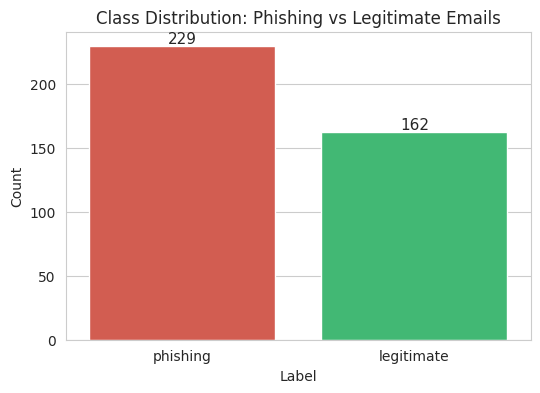

label
phishing      58.567775
legitimate    41.432225
Name: proportion, dtype: float64


In [5]:
# 3.1 Class distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(x='label', data=df, palette={'phishing':'#e74c3c','legitimate':'#2ecc71'})
plt.title('Class Distribution: Phishing vs Legitimate Emails')
plt.xlabel('Label')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()

print(df['label'].value_counts(normalize=True) * 100)


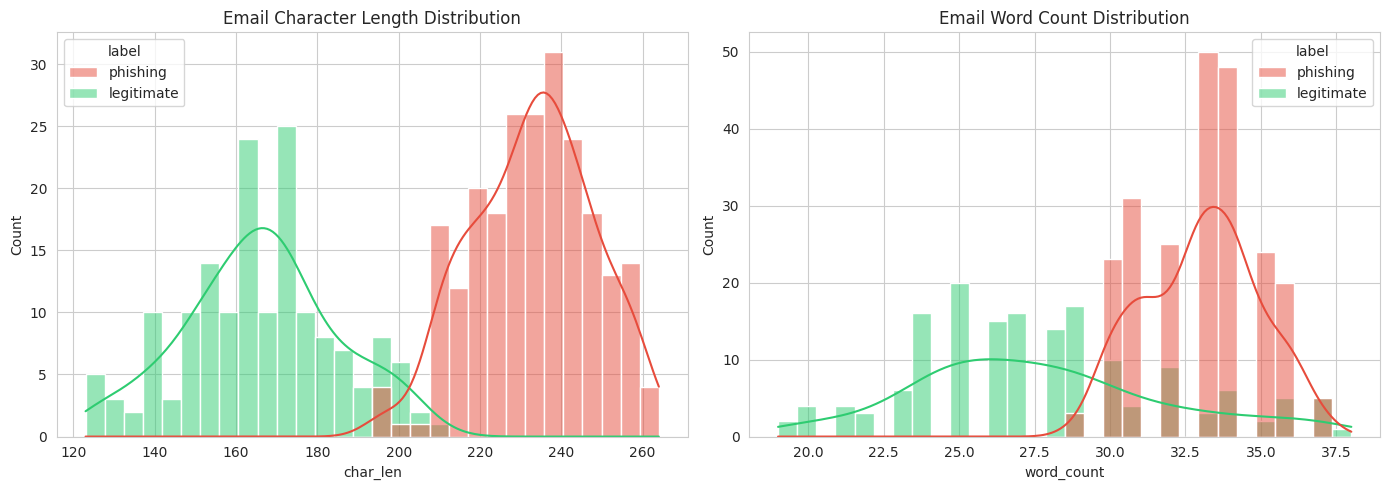

In [6]:
# 3.2 Email length distribution by class
df['char_len'] = df['email_text'].apply(len)
df['word_count'] = df['email_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(data=df, x='char_len', hue='label', bins=30, kde=True, ax=axes[0],
             palette={'phishing':'#e74c3c','legitimate':'#2ecc71'})
axes[0].set_title('Email Character Length Distribution')

sns.histplot(data=df, x='word_count', hue='label', bins=30, kde=True, ax=axes[1],
             palette={'phishing':'#e74c3c','legitimate':'#2ecc71'})
axes[1].set_title('Email Word Count Distribution')
plt.tight_layout()
plt.show()


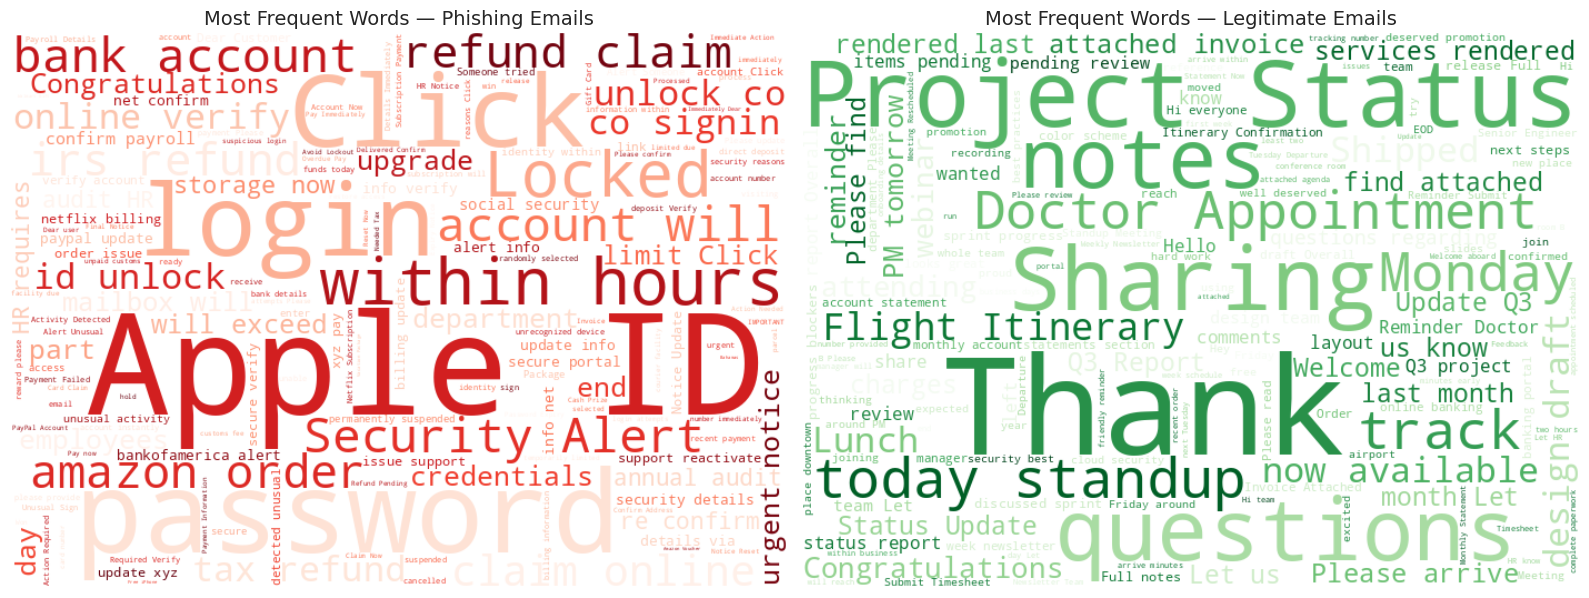

In [7]:
# 3.3 Word clouds for each class
phishing_text = " ".join(df[df['label'] == 'phishing']['email_text'])
legit_text = " ".join(df[df['label'] == 'legitimate']['email_text'])

fig, axes = plt.subplots(1, 2, figsize=(16,7))

wc_phish = WordCloud(width=700, height=500, background_color='white',
                      colormap='Reds').generate(phishing_text)
axes[0].imshow(wc_phish, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words — Phishing Emails', fontsize=14)

wc_legit = WordCloud(width=700, height=500, background_color='white',
                      colormap='Greens').generate(legit_text)
axes[1].imshow(wc_legit, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words — Legitimate Emails', fontsize=14)

plt.tight_layout()
plt.show()


## Step 4: Text Preprocessing (NLP Cleaning)

Standard NLP cleaning pipeline:
1. Lowercase text
2. Remove URLs, HTML tags, email addresses
3. Remove punctuation & digits
4. Tokenize
5. Remove stopwords
6. Lemmatize (reduce words to their root form)


In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' urltoken ', text)          # URLs -> token
    text = re.sub(r'\S+@\S+', ' emailtoken ', text)                        # emails -> token
    text = re.sub(r'<.*?>', ' ', text)                                     # HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)                                  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()                               # extra whitespace

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

df['clean_text'] = df['email_text'].apply(clean_text)
df[['email_text', 'clean_text']].head(5)


,email_text,clean_text
0,You've Won a $1000 Gift Card - Claim Now! This...,gift card claim urgent notice department mailb...
1,Your Amazon Order Could Not Be Processed As pa...,amazon order could processed part annual audit...
2,You've Won a $1000 Gift Card - Claim Now! Your...,gift card claim account temporarily limited du...
3,Weekly Newsletter: Team Updates Congratulation...,weekly newsletter team update congratulation w...
4,Welcome to the Team! This is a friendly remind...,welcome team friendly reminder submit timeshee...


In [9]:
# Compare a raw vs cleaned example
print("BEFORE CLEANING:\n", df['email_text'].iloc[0], "\n")
print("AFTER CLEANING:\n", df['clean_text'].iloc[0])


BEFORE CLEANING:
 You've Won a $1000 Gift Card - Claim Now! This is an urgent notice from the IT department. Your mailbox will exceed its limit. Click http://irs-refund-claim.online/verify and login with your credentials to upgrade your storage now. 

AFTER CLEANING:
 gift card claim urgent notice department mailbox exceed limit click urltoken login credential upgrade storage


## Step 5: Feature Extraction — TF-IDF Vectorization

We convert cleaned text into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**, which weighs words by how important/distinctive they are across the dataset.


In [10]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
X = tfidf.fit_transform(df['clean_text'])

# Encode labels: phishing = 1, legitimate = 0
y = df['label'].map({'phishing': 1, 'legitimate': 0})

print("Feature matrix shape:", X.shape)
print("Sample TF-IDF feature names:", tfidf.get_feature_names_out()[:20])


Feature matrix shape: (391, 702)
Sample TF-IDF feature names: ['aboard' 'aboard excited' 'access' 'access account' 'account'
 'account apple' 'account click' 'account congratulation' 'account dear'
 'account instantly' 'account limited' 'account number' 'account part'
 'account permanently' 'account statement' 'account suspended'
 'account tax' 'account temporarily' 'account unrecognized'
 'account urgent']


## Step 6: Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 312
Testing samples : 79


## Step 7: Model Training

We train and compare **4 classic ML models** commonly used for text classification:
- Multinomial Naive Bayes
- Logistic Regression
- Random Forest
- Linear SVM (calibrated for probability outputs)


In [12]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(max_iter=5000))
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    trained_models[name] = model
    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1-Score": f1})

    print(f"✅ {name} trained")

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df


✅ Naive Bayes trained
✅ Logistic Regression trained


✅ Random Forest trained
✅ Linear SVM trained


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Linear SVM,1.0,1.0,1.0,1.0


## Step 8: Model Evaluation & Visualization

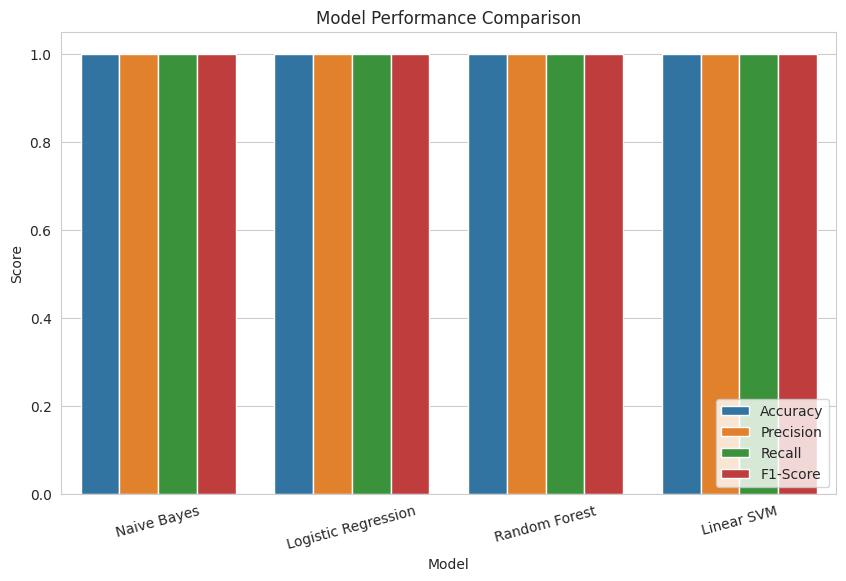

In [13]:
# 8.1 Accuracy / Precision / Recall / F1 comparison chart
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()


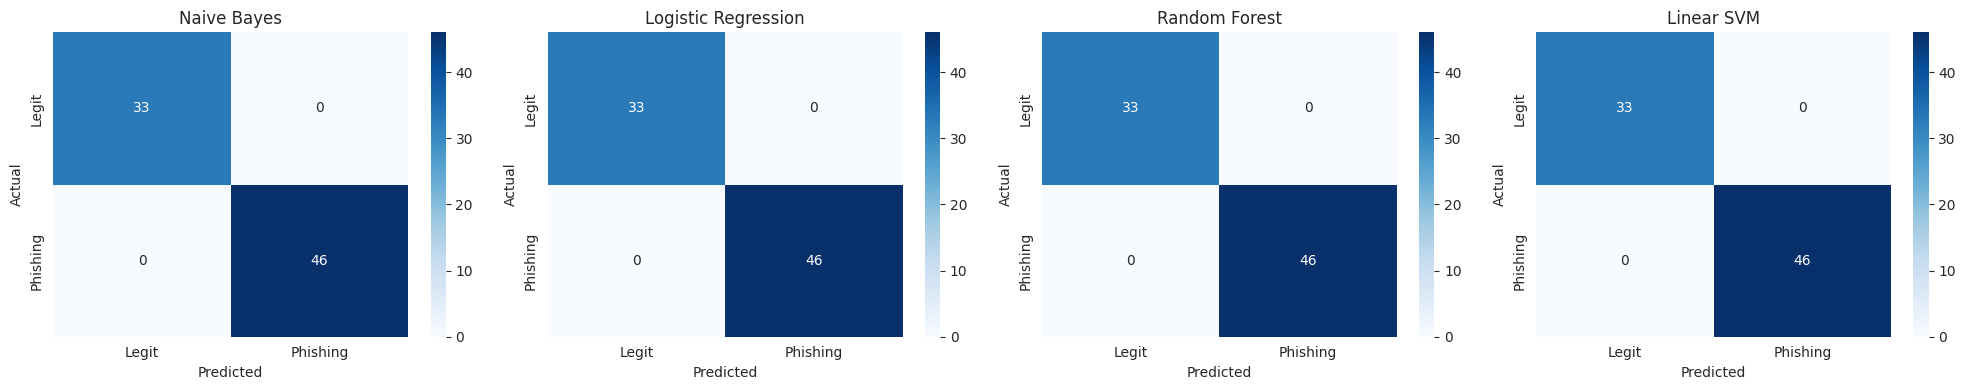

In [14]:
# 8.2 Confusion matrices for all models
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Phishing'], yticklabels=['Legit','Phishing'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [15]:
# 8.3 Detailed classification report for the BEST model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_preds = best_model.predict(X_test)

print(f"🏆 Best Model: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=['Legitimate','Phishing']))


🏆 Best Model: Naive Bayes

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00        33
    Phishing       1.00      1.00      1.00        46

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



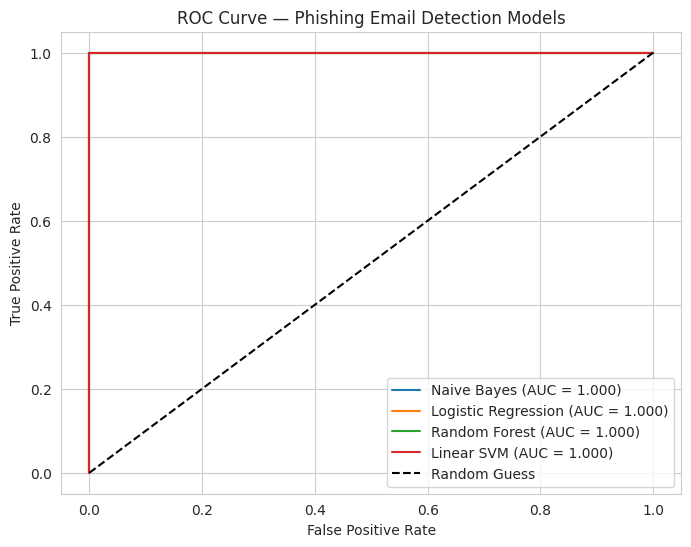

In [16]:
# 8.4 ROC Curves for all models
plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Phishing Email Detection Models')
plt.legend(loc='lower right')
plt.show()


## Step 9: Explainability — Top Indicator Words

Using Logistic Regression's coefficients, we can see which words push a prediction toward **phishing** vs **legitimate**.


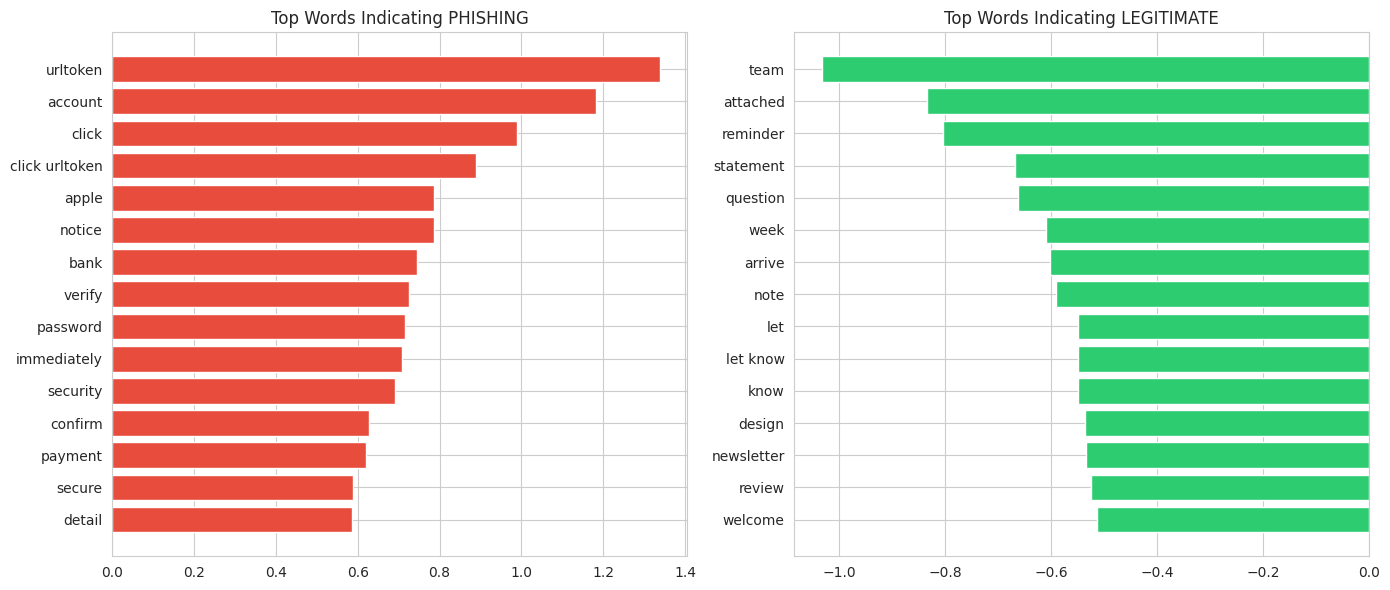

In [17]:
log_reg = trained_models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]

top_phishing_idx = np.argsort(coefs)[-15:][::-1]
top_legit_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].barh(feature_names[top_phishing_idx][::-1], coefs[top_phishing_idx][::-1], color='#e74c3c')
axes[0].set_title('Top Words Indicating PHISHING')

axes[1].barh(feature_names[top_legit_idx][::-1], coefs[top_legit_idx][::-1], color='#2ecc71')
axes[1].set_title('Top Words Indicating LEGITIMATE')

plt.tight_layout()
plt.show()


## Step 10: Test on a Custom / New Email

Try the trained model on any new email text you type in.


In [18]:
def predict_email(text, model=None, vectorizer=tfidf):
    if model is None:
        model = trained_models[best_model_name]
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]  # probability of being phishing
    label = "🚨 PHISHING" if pred == 1 else "✅ LEGITIMATE"
    return label, round(prob*100, 2)

# Example 1: a phishing-style email
sample_1 = "Dear user, your account has been suspended. Click here immediately to verify your password and bank details: http://secure-login-verify.com"
label, conf = predict_email(sample_1)
print(f"Email: {sample_1}\nPrediction: {label}  | Phishing Probability: {conf}%\n")

# Example 2: a normal/legitimate email
sample_2 = "Hi team, the meeting notes from today's standup are attached. Let me know if you have questions about the sprint plan."
label, conf = predict_email(sample_2)
print(f"Email: {sample_2}\nPrediction: {label}  | Phishing Probability: {conf}%")


Email: Dear user, your account has been suspended. Click here immediately to verify your password and bank details: http://secure-login-verify.com
Prediction: 🚨 PHISHING  | Phishing Probability: 99.51%

Email: Hi team, the meeting notes from today's standup are attached. Let me know if you have questions about the sprint plan.
Prediction: ✅ LEGITIMATE  | Phishing Probability: 0.28%


In [19]:
# 👉 Try your own email text here:
your_email = "PASTE ANY EMAIL TEXT HERE"
label, conf = predict_email(your_email)
print(f"Prediction: {label} | Phishing Probability: {conf}%")


Prediction: 🚨 PHISHING | Phishing Probability: 80.36%


## Step 11: Save the Trained Model

Save the best model + TF-IDF vectorizer so they can be reused later (e.g. in a web app or API) without retraining.


In [20]:
joblib.dump(best_model, "phishing_detector_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print(f"✅ Saved best model ({best_model_name}) and TF-IDF vectorizer to disk.")

# To reload later:
# loaded_model = joblib.load("phishing_detector_model.pkl")
# loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")


✅ Saved best model (Naive Bayes) and TF-IDF vectorizer to disk.


## 📚 Dataset Sources (for scaling up with real-world data)

This notebook ships with a small, ready-to-use `cleaned_phishing_email_dataset.csv` (391 labeled emails) so you can run the full pipeline immediately. To train on a **larger, real-world corpus**, download and merge any of these public datasets (just map their text/label columns to `email_text` / `label`):

| Dataset | Description | Link |
|---|---|---|
| Phishing Email Dataset (Enron, Ling, CEAS, Nazario, Nigerian Fraud & SpamAssassin combined) | ~large combined corpus of phishing + legitimate emails | https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset |
| Phishing Emails (Subhajournal) | Phishing vs safe email text body dataset | https://www.kaggle.com/datasets/subhajournal/phishingemails |
| ealvaradob/phishing-dataset (Hugging Face) | Combines Enron (18k+ emails), SMS, and URL phishing data; ready for `datasets` library | https://huggingface.co/datasets/ealvaradob/phishing-dataset |
| Human-LLM Generated Phishing & Legitimate Emails | 4000 emails (human + LLM-generated), based on Nazario & Nigerian Fraud datasets | https://www.kaggle.com/datasets/francescogreco97/human-llm-generated-phishing-legitimate-emails |
| The Biggest Spam Ham Phish Email Dataset (250,000+) | Large-scale spam/ham/phishing email dataset | https://www.kaggle.com/datasets/akshatgupta7/the-biggest-spam-ham-phish-email-dataset |
| Email Phishing Dataset (Cleaned & Feature-Engineered) | Pre-cleaned dataset with engineered features | https://www.kaggle.com/datasets/ethancratchley/email-phishing-dataset |
| Nazario Phishing Corpus (original) | Classic academic phishing email corpus | https://monkey.org/~jose/phishing/ |
| SpamAssassin Public Corpus | Classic ham/spam email corpus | https://spamassassin.apache.org/old/publiccorpus/ |

**Note:** Kaggle requires a free account + API key (`kaggle.json`) to download via the `kaggle` CLI/API. You can also click "Download" directly on the dataset page.

```python
# Example: downloading via Kaggle API (after placing kaggle.json in ~/.kaggle/)
# !pip install kaggle
# !kaggle datasets download -d naserabdullahalam/phishing-email-dataset --unzip
```
